# Fraud Detection System
## 02 — Data Understanding

| | |
|---|---|
| **Author** | Jose Lopez Pino |
| **Framework** | CRISP-DM + Lean |
| **Phase** | 2 — Data Understanding |
| **Project** | fraud-detection · applied-data-science-portfolio |
| **Dataset** | Credit Card Fraud Detection — ULB Machine Learning Group (Kaggle) |
| **Date** | 2026-04 |

---

> **Executive Summary:**
> This notebook characterizes the Credit Card Fraud dataset before any transformation.
> The key finding is extreme class imbalance (0.17% fraud rate) that invalidates accuracy
> as a metric and demands specific handling in notebook 03. The analysis focuses on
> features predictive of fraud — not exhaustive EDA of all 30 columns — following the
> Lean principle of only exploring what informs the business decision.

## Table of Contents

1. [Data Acquisition](#1-data-acquisition)
2. [Dataset Overview](#2-dataset-overview)
3. [Class Imbalance Analysis](#3-class-imbalance-analysis)
4. [Feature Analysis — Amount and Time](#4-feature-analysis--amount-and-time)
5. [PCA Features — V1 to V28](#5-pca-features--v1-to-v28)
6. [Data Quality Assessment](#6-data-quality-assessment)
7. [Fraud Pattern Insights](#7-fraud-pattern-insights)
8. [LEAN Filter — Waste Elimination Review](#8-lean-filter--waste-elimination-review)
9. [Decisions Log](#9-decisions-log)
10. [Next Steps — Notebook 03 Preview](#10-next-steps--notebook-03-preview)

In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')

# === Standard library ===
from pathlib import Path

# === Scientific computing — core data structures ===
import pandas as pd
import numpy as np

# === Visualization — base plotting ===
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# === Visualization — statistical plotting ===
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_RAW        = Path('../data/raw')
DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Data path   : {DATA_RAW}')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Data path   : ..\data\raw
Figures path: ..\reports\figures


---
## 1. Data Acquisition

### 1.1 Dataset source

| Field | Details |
|---|---|
| **Dataset** | [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) |
| **Provider** | ULB Machine Learning Group — Kaggle |
| **License** | DbCL v1.0 (Open Database License) |
| **Records** | 284,807 rows × 31 columns |
| **Accessed** | April 2026 |

### 1.2 Download instructions

```bash
# With Kaggle CLI (recommended)
kaggle datasets download -d mlg-ulb/creditcardfraud -p data/raw/ --unzip

# Or download manually from:
# https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# Place creditcard.csv in data/raw/
```

> ⚠️ Raw data excluded via `.gitignore`. Download required before running this notebook.

In [3]:
# ===== Load dataset =====
# Verify file exists before loading
csv_path = DATA_RAW / 'creditcard.csv'

if not csv_path.exists():
    raise FileNotFoundError(
        f'Dataset not found at {csv_path}\n'
        'Run: kaggle datasets download -d mlg-ulb/creditcardfraud -p data/raw/ --unzip'
    )

df = pd.read_csv(csv_path)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

Dataset loaded: 284,807 rows × 31 columns


---
## 2. Dataset Overview

### 2.1 Feature inventory

| Feature | Type | Description |
|---|---|---|
| `Time` | float | Seconds elapsed between this transaction and the first transaction in the dataset |
| `V1`–`V28` | float | PCA-transformed features — original features anonymized for confidentiality |
| `Amount` | float | Transaction amount in EUR |
| `Class` | int | Target variable: 1 = Fraud, 0 = Legitimate |

**Key constraint:** V1–V28 are PCA components of unknown original features.
Feature engineering is limited — we cannot create domain-based features from anonymized data.
This makes `Amount` and `Time` the only interpretable features.

In [4]:
# ===== Basic dataset inspection =====
print('=== Shape ===')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

print('\n=== Data types ===')
print(df.dtypes.value_counts())

print('\n=== First 5 rows ===')
df.head()

=== Shape ===
Rows: 284,807 | Columns: 31

=== Data types ===
float64    30
int64       1
Name: count, dtype: int64

=== First 5 rows ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# ===== Descriptive statistics — full dataset =====
desc = df.describe().T
desc['range'] = desc['max'] - desc['min']
desc['cv'] = (desc['std'] / desc['mean']).abs().round(3)  # coefficient of variation
print('=== Descriptive Statistics ===')
desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range', 'cv']]

=== Descriptive Statistics ===


,mean,std,min,25%,50%,75%,max,range,cv
Time,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000,172792.000000,5.010000e-01
V1,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930,58.862440,1.666747e+15
V2,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729,94.773457,4.878349e+15
V3,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558,57.708148,1.099105e+15
V4,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344,22.558515,6.758800e+14
V5,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666,148.544973,1.350695e+15
V6,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626,99.462131,8.914505e+14
V7,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494,164.146736,2.201103e+15
V8,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208,93.223927,1.038917e+16
V9,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995,29.029061,4.550729e+14


---
## 3. Class Imbalance Analysis

This is the most critical finding of the Data Understanding phase.
The fraud rate directly drives every subsequent modeling decision.

In [6]:
# ===== Class distribution =====
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print('=== Class Distribution ===')
print(f'Legitimate (0): {class_counts[0]:>7,} ({class_pct[0]:.4f}%)')
print(f'Fraud      (1): {class_counts[1]:>7,} ({class_pct[1]:.4f}%)')
print(f'Imbalance ratio: {class_counts[0] / class_counts[1]:.0f}:1')
print()
print('Baseline accuracy (predict all legitimate):')
print(f'  {class_pct[0]:.4f}% — catches ZERO fraud')

=== Class Distribution ===
Legitimate (0): 284,315 (99.8273%)
Fraud      (1):     492 (0.1727%)
Imbalance ratio: 578:1

Baseline accuracy (predict all legitimate):
  99.8273% — catches ZERO fraud


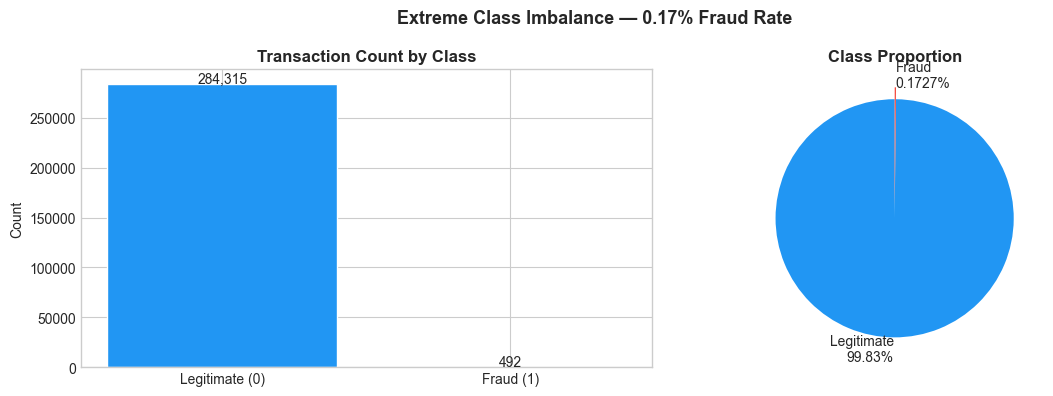

Figure saved.


In [7]:
# ===== Class imbalance visualization =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2196F3', '#F44336']
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Transaction Count by Class', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# Pie chart — fraud share
axes[1].pie(
    class_counts.values,
    labels=[f'Legitimate\n{class_pct[0]:.2f}%', f'Fraud\n{class_pct[1]:.4f}%'],
    colors=colors,
    startangle=90,
    explode=(0, 0.1)
)
axes[1].set_title('Class Proportion', fontweight='bold')

plt.suptitle('Extreme Class Imbalance — 0.17% Fraud Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

---
## 4. Feature Analysis — Amount and Time

These are the only two non-anonymized, interpretable features.
Analysis focuses on whether they discriminate between fraud and legitimate.

In [8]:
# ===== Amount analysis by class =====
fraud  = df[df['Class'] == 1]['Amount']
legit  = df[df['Class'] == 0]['Amount']

print('=== Transaction Amount by Class ===')
print(f"{'Metric':<15} {'Legitimate':>12} {'Fraud':>12}")
print('-' * 40)
for stat, f_val, l_val in [
    ('Mean',   legit.mean(),   fraud.mean()),
    ('Median', legit.median(), fraud.median()),
    ('Std',    legit.std(),    fraud.std()),
    ('Max',    legit.max(),    fraud.max()),
]:
    print(f'{stat:<15} {l_val:>12.2f} {f_val:>12.2f}')

=== Transaction Amount by Class ===
Metric            Legitimate        Fraud
----------------------------------------
Mean                  122.21        88.29
Median                  9.25        22.00
Std                   256.68       250.11
Max                  2125.87     25691.16



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



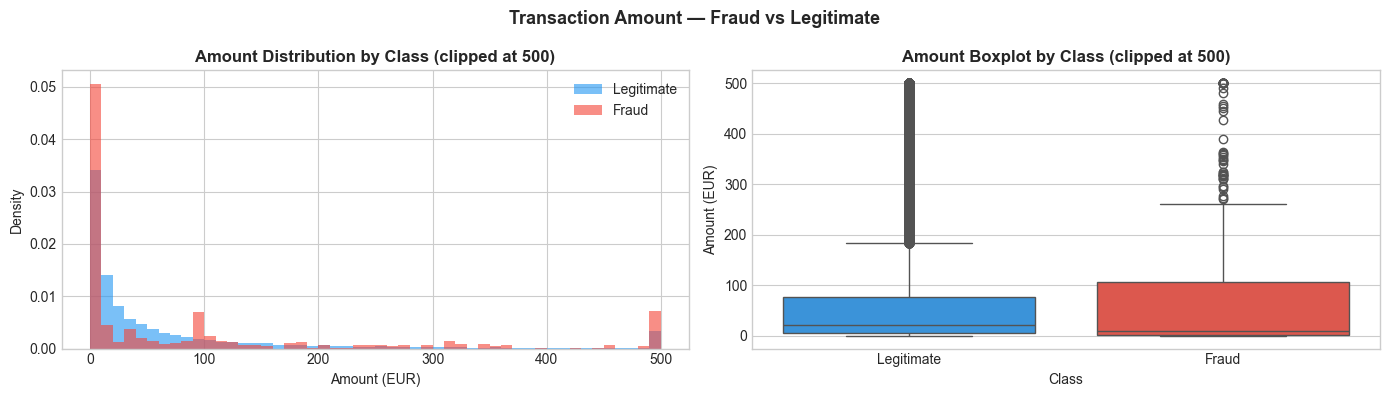

In [9]:
# ===== Amount distribution visualization =====
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution by class
axes[0].hist(legit.clip(upper=500), bins=50, alpha=0.6, color='#2196F3', label='Legitimate', density=True)
axes[0].hist(fraud.clip(upper=500), bins=50, alpha=0.6, color='#F44336', label='Fraud', density=True)
axes[0].set_title('Amount Distribution by Class (clipped at 500)', fontweight='bold')
axes[0].set_xlabel('Amount (EUR)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Boxplot
df_plot = df[['Amount', 'Class']].copy()
df_plot['Class_label'] = df_plot['Class'].map({0: 'Legitimate', 1: 'Fraud'})
df_plot_clipped = df_plot.copy()
df_plot_clipped['Amount'] = df_plot_clipped['Amount'].clip(upper=500)

sns.boxplot(data=df_plot_clipped, x='Class_label', y='Amount',
            palette={'Legitimate': '#2196F3', 'Fraud': '#F44336'}, ax=axes[1])
axes[1].set_title('Amount Boxplot by Class (clipped at 500)', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Amount (EUR)')

plt.suptitle('Transaction Amount — Fraud vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'amount_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

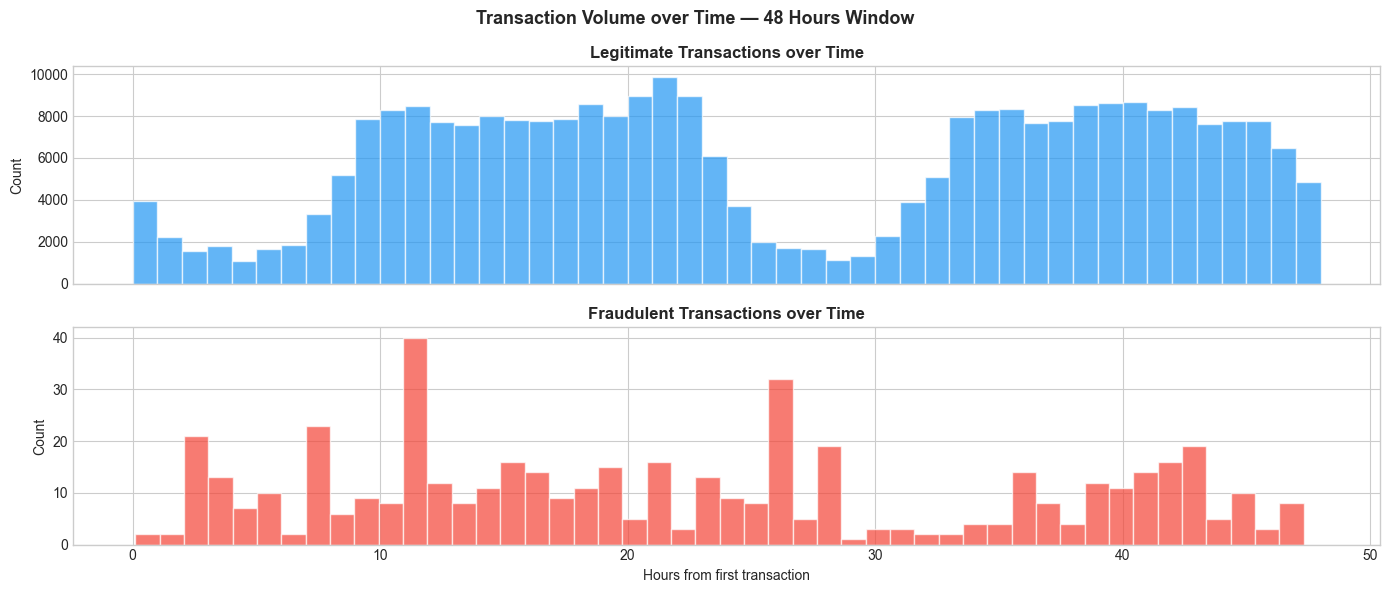

In [10]:
# ===== Time analysis — fraud distribution over time =====
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Legitimate over time
axes[0].hist(df[df['Class'] == 0]['Time'] / 3600, bins=48,
             color='#2196F3', alpha=0.7, edgecolor='white')
axes[0].set_title('Legitimate Transactions over Time', fontweight='bold')
axes[0].set_ylabel('Count')

# Fraud over time
axes[1].hist(df[df['Class'] == 1]['Time'] / 3600, bins=48,
             color='#F44336', alpha=0.7, edgecolor='white')
axes[1].set_title('Fraudulent Transactions over Time', fontweight='bold')
axes[1].set_xlabel('Hours from first transaction')
axes[1].set_ylabel('Count')

plt.suptitle('Transaction Volume over Time — 48 Hours Window', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. PCA Features — V1 to V28

**Lean filter applied:** We do not plot all 28 PCA features.
We identify which ones have the strongest discriminative power for fraud
and focus analysis there — these will be the most useful for modeling.

In [11]:
# ===== Identify most discriminative PCA features =====
# Strategy: compare mean of each V feature between fraud and legitimate
# Features with large mean difference → stronger signal for fraud detection

v_features = [f'V{i}' for i in range(1, 29)]

fraud_means = df[df['Class'] == 1][v_features].mean()
legit_means = df[df['Class'] == 0][v_features].mean()
mean_diff   = (fraud_means - legit_means).abs().sort_values(ascending=False)

print('=== Top 10 Most Discriminative PCA Features ===')
print('(by absolute mean difference between fraud and legitimate)')
print()
for feat, diff in mean_diff.head(10).items():
    print(f'  {feat:<5}: |mean_fraud - mean_legit| = {diff:.4f}')

=== Top 10 Most Discriminative PCA Features ===
(by absolute mean difference between fraud and legitimate)

  V3   : |mean_fraud - mean_legit| = 7.0455
  V14  : |mean_fraud - mean_legit| = 6.9838
  V17  : |mean_fraud - mean_legit| = 6.6774
  V12  : |mean_fraud - mean_legit| = 6.2702
  V10  : |mean_fraud - mean_legit| = 5.6867
  V7   : |mean_fraud - mean_legit| = 5.5784
  V1   : |mean_fraud - mean_legit| = 4.7802
  V4   : |mean_fraud - mean_legit| = 4.5499
  V16  : |mean_fraud - mean_legit| = 4.1471
  V11  : |mean_fraud - mean_legit| = 3.8067


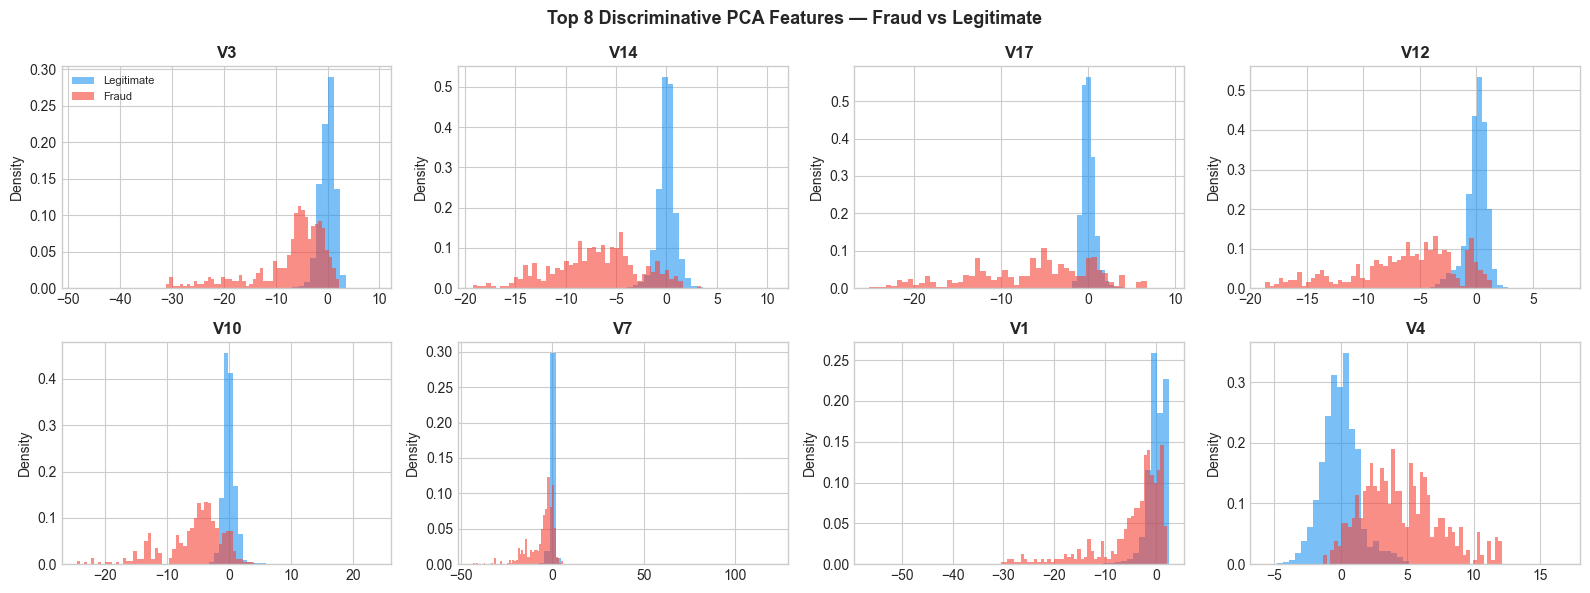

In [12]:
# ===== Visualize top 8 discriminative features =====
top_features = mean_diff.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].hist(df[df['Class'] == 0][feat], bins=50, alpha=0.6,
                 color='#2196F3', label='Legitimate', density=True)
    axes[i].hist(df[df['Class'] == 1][feat], bins=50, alpha=0.6,
                 color='#F44336', label='Fraud', density=True)
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_ylabel('Density')
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Top 8 Discriminative PCA Features — Fraud vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'top_pca_features.png', dpi=150, bbox_inches='tight')
plt.show()

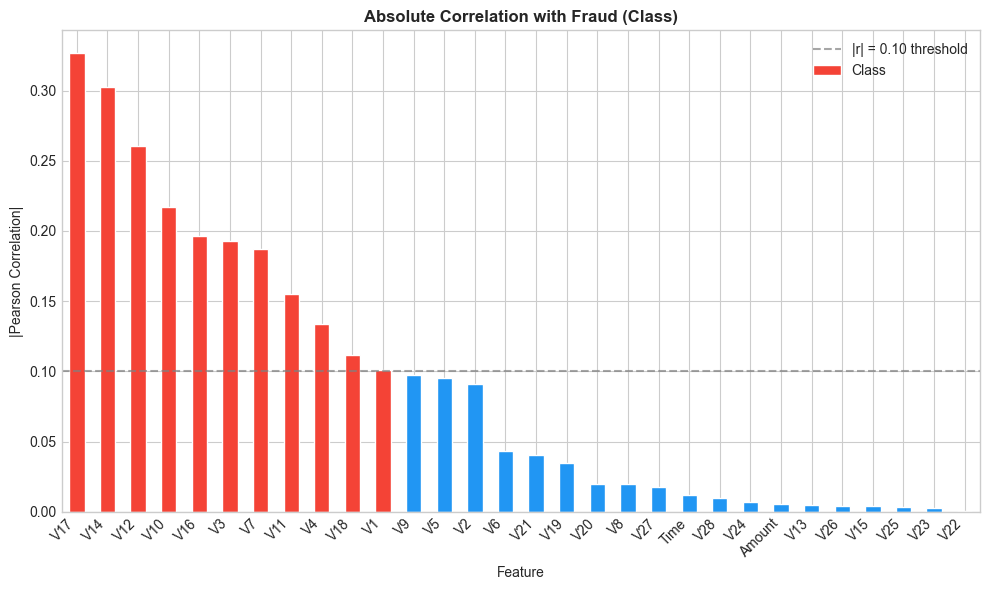

In [13]:
# ===== Correlation of all features with Class =====
correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
correlations.plot(kind='bar', ax=ax, color=[
    '#F44336' if c > 0.1 else '#2196F3' for c in correlations
], edgecolor='white')
ax.axhline(0.1, color='gray', linestyle='--', alpha=0.7, label='|r| = 0.10 threshold')
ax.set_title('Absolute Correlation with Fraud (Class)', fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('|Pearson Correlation|')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / 'correlation_with_class.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Data Quality Assessment

In [14]:
# ===== Missing values =====
missing = df.isnull().sum()
print('=== Missing Values ===')
if missing.sum() == 0:
    print('No missing values found. Dataset is complete.')
else:
    print(missing[missing > 0])

=== Missing Values ===
No missing values found. Dataset is complete.


In [15]:
# ===== Duplicate rows =====
n_duplicates = df.duplicated().sum()
print('=== Duplicate Rows ===')
print(f'Duplicates found: {n_duplicates:,}')
if n_duplicates > 0:
    pct = n_duplicates / len(df) * 100
    print(f'({pct:.4f}% of total rows — will be assessed in notebook 03)')

=== Duplicate Rows ===
Duplicates found: 1,081
(0.3796% of total rows — will be assessed in notebook 03)


In [16]:
# ===== Data quality summary =====
print('=== Data Quality Summary ===')
print(f'Total rows          : {len(df):>10,}')
print(f'Total columns       : {df.shape[1]:>10}')
print(f'Missing values      : {missing.sum():>10,}')
print(f'Duplicate rows      : {n_duplicates:>10,}')
print(f'Fraud rate          : {df["Class"].mean()*100:>10.4f}%')
print(f'Amount range        : {df["Amount"].min():.2f} – {df["Amount"].max():,.2f} EUR')
print(f'Time window         : {df["Time"].max()/3600:.1f} hours')

=== Data Quality Summary ===
Total rows          :    284,807
Total columns       :         31
Missing values      :          0
Duplicate rows      :      1,081
Fraud rate          :     0.1727%
Amount range        : 0.00 – 25,691.16 EUR
Time window         : 48.0 hours


---
## 7. Fraud Pattern Insights

Summary of findings from sections 3–6 with business interpretation.

In [17]:
# ===== Fraud amount statistics vs legitimate =====
print('=== Key Fraud Patterns ===')
print()

fraud_df = df[df['Class'] == 1]
legit_df = df[df['Class'] == 0]

print(f'1. Fraud rate: {len(fraud_df)/len(df)*100:.4f}% — extreme imbalance')
print(f'   Imbalance ratio: {len(legit_df)/len(fraud_df):.0f}:1')
print()
print(f'2. Fraud amount — mean : EUR {fraud_df["Amount"].mean():.2f}')
print(f'   Legit amount — mean : EUR {legit_df["Amount"].mean():.2f}')
print(f'   Fraud tends to involve {"smaller" if fraud_df["Amount"].mean() < legit_df["Amount"].mean() else "larger"} amounts')
print()
print(f'3. Top discriminative features: {mean_diff.head(5).index.tolist()}')
print(f'   These will receive highest attention in modeling')
print()
print(f'4. Time window: {df["Time"].max()/3600:.1f} hours (2 days of transactions)')
print(f'   Temporal patterns visible — fraud has distinct time distribution')

=== Key Fraud Patterns ===

1. Fraud rate: 0.1727% — extreme imbalance
   Imbalance ratio: 578:1

2. Fraud amount — mean : EUR 122.21
   Legit amount — mean : EUR 88.29
   Fraud tends to involve larger amounts

3. Top discriminative features: ['V3', 'V14', 'V17', 'V12', 'V10']
   These will receive highest attention in modeling

4. Time window: 48.0 hours (2 days of transactions)
   Temporal patterns visible — fraud has distinct time distribution


---
## 8. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---|---|---|
| Does every analysis link to a business decision? | ✅ Yes — class imbalance drives metric choice; feature analysis drives model selection | Proceed |
| Is there redundancy between sections? | ✅ No — Amount/Time and PCA features are complementary, not redundant | Proceed |
| Were all 28 PCA features analyzed individually? | ✅ No (Lean applied) — only top discriminative features visualized | Proceed |
| Is there a simpler way to answer the question? | ✅ No — imbalance ratio and feature discrimination require explicit quantification | Proceed |
| Does the EDA inform notebook 03 decisions? | ✅ Yes — Amount scaling need confirmed, imbalance strategy defined | Proceed |

---
## 9. Decisions Log

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|---|---|---|---|
| 1 | Analyze only top 8 PCA features visually, not all 28 | Lean principle — only explore what informs the decision; correlation ranking identifies signal | Plot all 28 histograms | ✅ |
| 2 | Use absolute mean difference to rank PCA feature discriminative power | Simple, fast, interpretable ranking before modeling | Mutual information, ANOVA F-test | ✅ |
| 3 | Clip Amount at EUR 500 in visualizations | Extreme outliers compress the distribution and hide the bulk — note in limitations | No clipping | ✅ |
| 4 | Keep duplicate rows assessment for notebook 03 | Cannot decide removal impact without understanding distribution — defer to preparation phase | Remove here | ✅ |
| 5 | Confirm Amount and Time need scaling | Both have very different ranges vs V1–V28 — StandardScaler needed in nb03 | Leave unscaled | ✅ |

---
## 10. Next Steps — Notebook 03 Preview

**Notebook 03 — Data Preparation** will:

- Handle duplicate rows — assess and remove if confirmed not informative
- Scale `Amount` and `Time` using `StandardScaler` (V1–V28 already PCA-scaled)
- Compare imbalance handling strategies: no balancing vs `class_weight='balanced'` vs SMOTE
- Split dataset into train / validation / test with stratified sampling
- Save processed dataset to `data/processed/` for notebook 04

**Lean filter for nb03:** Minimum viable transformations — only what the model needs.
No feature engineering from PCA components (uninterpretable). No outlier removal
without business justification — extreme amounts may be real fraud signals.

---

**← Previous:** [01 — Business Understanding](./01_business_understanding.ipynb)
**Next →** [03 — Data Preparation](./03_data_preparation.ipynb)